# Face Detection and Recognition

The `data` directory contains three folders 30 face images of three players from the 2024 Philadelphia Phillies: Alec Bohm, Bryson Stott, and Brandon Marsh. In addition, the `Samples` directory contains three images of a combination of those players.

This project attempts to correctly detect and identify Bohm, Stott, and Marsh in the three sample images.

### Install Tensorflow 2.9.2

In [1]:
import subprocess
import sys
from IPython.display import clear_output
def check_tensorflow():
    tf_desired_version = "2.9.2"

    try:
        import tensorflow as tf
        tf_installed_version = tf.__version__
    except ImportError:
        tf_installed_version = None

    #Check for the right version
    if tf_installed_version != tf_desired_version:
        print(f"Current TensorFlow version: {tf_installed_version}. Installing version {tf_desired_version}...")
        
        # Uninstall the current TensorFlow version
        subprocess.check_call([sys.executable, '-m', 'pip', 'uninstall', '-y', 'tensorflow'])
        
        # Install the desired TensorFlow version
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', f'tensorflow=={tf_desired_version}'])

        clear_output()
        
        print(f"TensorFlow version {tf_desired_version} installed successfully. Please restart your kernel to apply the changes.")
    else:
        print(f"TensorFlow version {tf_desired_version} is already installed.")    

check_tensorflow()

TensorFlow version 2.9.2 is already installed.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mtcnn.mtcnn import MTCNN
%matplotlib inline
from PIL import Image, ImageOps
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import ConfusionMatrixDisplay as cmd
from tensorflow.keras.models import load_model
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Resizing


ModuleNotFoundError: No module named 'MTCNN'

In [3]:
import os

def load_images_from_path(path, label):
    images, labels = [], []
    for file in os.listdir(path):
        images.append(image.img_to_array(image.load_img(os.path.join(path, file), target_size=(224, 224, 3))))
        labels.append((label))
    return images, labels
    
def show_images(images):
    fig, axes = plt.subplots(1, 8, figsize=(20, 20), subplot_kw={'xticks': [], 'yticks': []})
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i] / 255)
x, y = [],[]

In [4]:
images, labels = load_images_from_path('data/Bohm', 0)
show_images(images)
x += images
y += labels

NameError: name 'image' is not defined

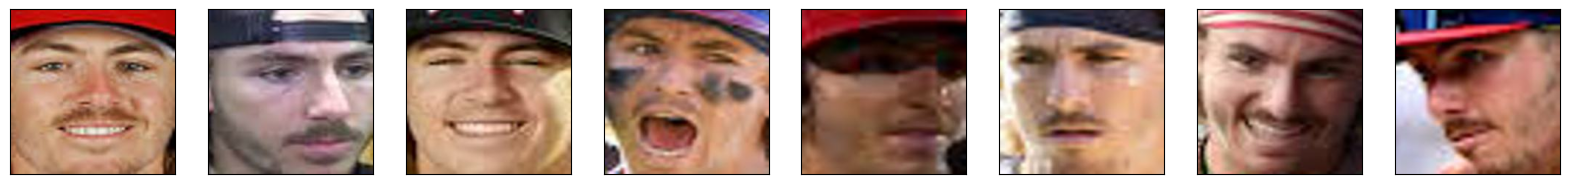

In [142]:
images, labels = load_images_from_path('data/Stott', 1)
show_images(images)
x += images
y += labels

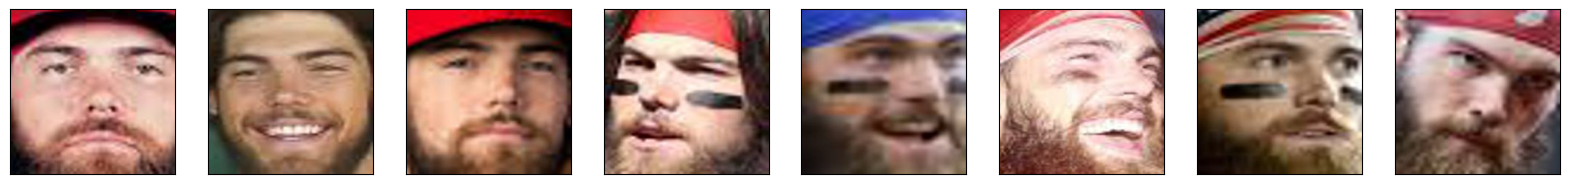

In [143]:
images, labels = load_images_from_path('data/Marsh', 2)
show_images(images)
x += images
y += labels

In [144]:
faces = preprocess_input(np.array(x))
labels = np.array(y)
x_train, x_test, y_train, y_test = train_test_split(faces, labels, train_size=0.5, stratify=labels, random_state=0)

In [145]:
base_model = load_model('data/vggface.h5')
base_model.trainable = False

In [202]:
model = Sequential()
model.add(Resizing(224, 224))
model.add(base_model)
model.add(Flatten())
model.add(Dense(9, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [214]:
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=3, epochs=20)

Epoch 1/20
5/5 [==============================] - 4s 858ms/step - loss: 1.9960e-04 - accuracy: 1.0000 - val_loss: 0.2021 - val_accuracy: 0.9333
Epoch 2/20
5/5 [==============================] - 3s 754ms/step - loss: 1.9415e-04 - accuracy: 1.0000 - val_loss: 0.2016 - val_accuracy: 0.9333
Epoch 3/20
5/5 [==============================] - 4s 789ms/step - loss: 1.9143e-04 - accuracy: 1.0000 - val_loss: 0.2011 - val_accuracy: 0.9333
Epoch 4/20
5/5 [==============================] - 3s 720ms/step - loss: 1.8590e-04 - accuracy: 1.0000 - val_loss: 0.2004 - val_accuracy: 0.9333
Epoch 5/20
5/5 [==============================] - 3s 677ms/step - loss: 1.7972e-04 - accuracy: 1.0000 - val_loss: 0.1998 - val_accuracy: 0.9333
Epoch 6/20
5/5 [==============================] - 3s 670ms/step - loss: 1.7526e-04 - accuracy: 1.0000 - val_loss: 0.1993 - val_accuracy: 0.9333
Epoch 7/20
5/5 [==============================] - 3s 683ms/step - loss: 1.7241e-04 - accuracy: 1.0000 - val_loss: 0.1987 - val_accuracy:

In [ ]:
def get_face(image, face):
    x1, y1, w, h = face['box']
    if w > h:
        x1 = x1 + ((w - h) // 2)
        w = h
    elif h > w:
        y1 = y1 + ((h - w) // 2)
        h = w
    x2 = x1 + h
    y2 = y1 + w
    return image[y1:y2, x1:x2]

def label_faces(path, model, names, face_threshold=0.9, prediction_threshold=0.9, show_outline=True, size=(12, 8)):
    # Load the image and orient it correctly
    pil_image = Image.open(path)
    exif = pil_image.getexif()
    
    for k in exif.keys():
        if k != 0x0112:
            exif[k] = None
            del exif[k]

    pil_image.info["exif"] = exif.tobytes()
    pil_image = ImageOps.exif_transpose(pil_image)
    np_image = np.array(pil_image)

    fig, ax = plt.subplots(figsize=size, subplot_kw={'xticks': [], 'yticks': []})
    ax.imshow(np_image)

    detector = MTCNN()
    faces = detector.detect_faces(np_image)
    faces = [face for face in faces if face['confidence'] > face_threshold]

    for face in faces:
        x, y, w, h = face['box']
        
        # identify the face
        face_image = get_face(np_image, face)
        face_image = image.array_to_img(face_image)
        face_image = preprocess_input(np.array(face_image))
        predictions = model.predict(np.expand_dims(face_image, axis=0))
        confidence = np.max(predictions)

        if (confidence > prediction_threshold):
            # draw a box around the face
            if show_outline:
                rect = Rectangle((x, y), w, h, color='red', fill=False, lw=2)
                ax.add_patch(rect)
            
            # Label the face
            index = int(np.argmax(predictions))
            text = f'{names[index]} ({confidence:.1%})'
            ax.text(x + (w / 2), y, text, color='white', backgroundcolor='red', ha='center', va='bottom', fontweight='bold', bbox=dict(color='red'))


1/1 [==============================] - 0s 131ms/step


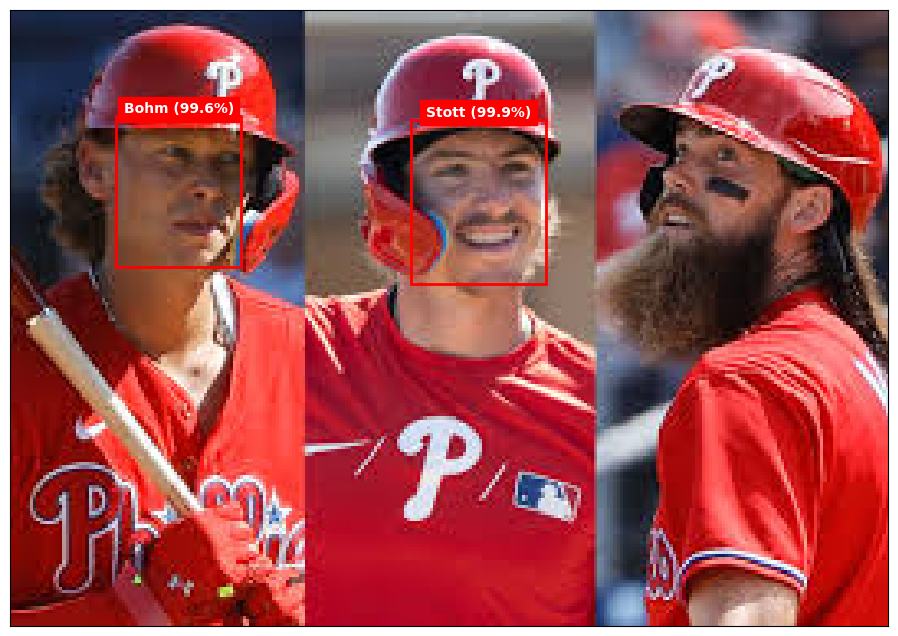

In [222]:
labels = ['Bohm', 'Stott', 'Marsh']
label_faces('data/Samples/Sample-3.jpeg', model, labels)

In [ ]:
# Making predictions

def make_pred(path, model, names, face_threshold=0.9, prediction_threshold=0.9, show_outline=True, size=(12, 8)):
    # Load the image and orient it correctly
    pil_image = Image.open(path)
    exif = pil_image.getexif()
    
    for k in exif.keys():
        if k != 0x0112:
            exif[k] = None
            del exif[k]
            
    pil_image.info["exif"] = exif.tobytes()
    pil_image = ImageOps.exif_transpose(pil_image)
    np_image = np.array(pil_image)

    detector = MTCNN()
    faces = detector.detect_faces(np_image)
    faces = [face for face in faces if face['confidence'] > face_threshold]

    for face in faces:
        x, y, w, h = face['box']

        # identify the face
        face_image = get_face(np_image, face)
        face_image = image.array_to_img(face_image)
        face_image = preprocess_input(np.array(face_image))
        predictions = model.predict(np.expand_dims(face_image, axis=0))
        confidence = np.max(predictions)

        if (confidence > prediction_threshold):
            return predictions
            

        return None
        
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img_array

def get_all_images_from_directory(directory):
    images = []
    labels = []
    images_names = []
    for label in os.listdir(directory):
        label_path = os.path.join(directory, label)
        if os.path.isdir(label_path):
            images_names += [img for img in os.listdir(label_path)]
            images += [os.path.join(label_path, img) for img in os.listdir(label_path)]
            labels += [int(label)] * len(os.listdir(label_path))
    
    # Embaralhar as imagens e labels
    combined = list(zip(images_names, images, labels))
    random.shuffle(combined)
    images_names, images, labels = zip(*combined)
    
    #return images_names, images, labels
    return zip(*combined)

def predict_and_validate(model, image_names, image_paths, true_labels, class_labels):
    predictions = []
    for img_path in image_paths:
        predictions.append(make_pred(img_path, model, class_labels, prediction_threshold=0.8))
    
    results = [true == pred for true, pred in zip(true_labels, predictions)]
    
    df = pd.DataFrame({
        'Player': image_names,
        'Prediction Array': predictions
    })
    
    return df

ModuleNotFoundError: No module named 'mtcnn'

In [ ]:
from IPython.display import clear_output

model_to_evaluate = model

class_labels = {0: 'Alec Bohm', 1: 'Bryson Stott', 2: 'Brandon Marsh'}  
image_names, image_paths, true_labels = get_all_images_from_directory('data/test/')
prediction_df = predict_and_validate(model_to_evaluate, image_names, image_paths, true_labels, class_labels)
clear_output()
prediction_df

,Player,Prediction Array
0,alec_01.jpg,"[[0.9999025, 2.9268815e-05, 6.816336e-05]]"
1,Bryson_06.png,"[[0.00044172496, 0.9995065, 5.1773757e-05]]"
2,Brandon_03.png,"[[0.011282335, 7.578546e-05, 0.9886419]]"
3,Bryson_09.png,"[[6.2694126e-06, 0.99998856, 5.1094553e-06]]"
4,alec_02.jpg,"[[0.9999459, 2.8282877e-05, 2.5907237e-05]]"
5,Brandon_04.png,"[[4.803709e-05, 3.398028e-08, 0.99995196]]"
6,alec_07.jpg,"[[0.99971634, 0.00027393803, 9.673529e-06]]"
7,Brandon_08.png,"[[0.015886845, 4.519601e-05, 0.984068]]"
8,Bryson_04.png,"[[1.84391e-07, 0.99999917, 5.4296305e-07]]"
9,Brandon_07.png,"[[0.0009201314, 5.0312074e-06, 0.9990748]]"
